# Data Visualization for covid testing January 26, 2020 - April 4, 2023 in Ontario #

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# load data
df = pd.read_csv('covidtesting.csv')

## Visualization 1

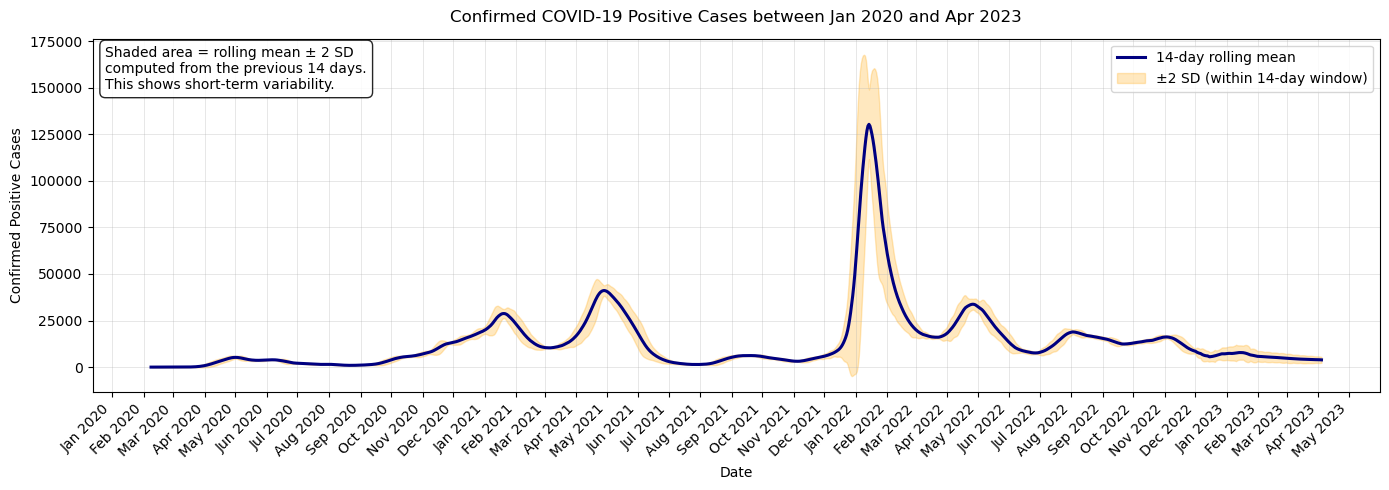

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1) Load data
# -----------------------------
df = pd.read_csv('covidtesting.csv')

# -----------------------------
# 2) Clean / prep
# -----------------------------
df["Reported Date"] = pd.to_datetime(df["Reported Date"], errors="coerce")
df = df.sort_values("Reported Date")

# Ensure numeric (coerce non-numeric to NaN)
df["Confirmed Positive"] = pd.to_numeric(df["Confirmed Positive"], errors="coerce")

# Drop rows missing key fields (date or cases)
df = df.dropna(subset=["Reported Date", "Confirmed Positive"])

x = df["Reported Date"]
y = df["Confirmed Positive"]

# -----------------------------
# 3) Rolling mean + ±2 SD band
# -----------------------------
window_days = 14  # change to 7 if you want a weekly window
rolling_mean = y.rolling(window=window_days, min_periods=1).mean()
rolling_std = y.rolling(window=window_days, min_periods=1).std()

upper = rolling_mean + 2 * rolling_std
lower = rolling_mean - 2 * rolling_std

# -----------------------------
# 4) Plot (monthly labels + color contrast + annotation)
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))

# Main smoothed trend line (high contrast)
ax.plot(
    x,
    rolling_mean,
    linewidth=2.2,
    color="navy",
    label=f"{window_days}-day rolling mean"
)

# ±2 SD variability band (contrasting fill)
ax.fill_between(
    x.values,
    lower.values,
    upper.values,
    alpha=0.25,
    color="orange",
    label=f"±2 SD (within {window_days}-day window)"
)

ax.set_title(f"Confirmed COVID-19 Positive Cases between Jan 2020 and Apr 2023", pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Confirmed Positive Cases")

# Monthly ticks for readability
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

# Grid + legend
ax.grid(True, linewidth=0.6, alpha=0.35)
ax.legend(loc="upper right")

# Explanation on the graph for interpretation
explain_text = (
    f"Shaded area = rolling mean ± 2 SD\n"
    f"computed from the previous {window_days} days.\n"
    f"This shows short-term variability."
)
ax.text(
    0.01, 0.98, explain_text,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
)

plt.tight_layout()
plt.show()


### What software did you use to create your data visualization?
I used Python, with pandas for loading and cleaning the data and matplotlib for creating the visualizations.

### Who is your intended audience?
The intended audience is a general public health and academic audience, including classmates, instructors, and non-technical stakeholders who want to understand COVID-19 case trends.

### What information or message are you trying to convey with your visualization?
The visualization shows how confirmed COVID-19 cases changed over time while also highlighting how much short-term variability existed around those trends.

### What aspects of design did you consider when making your visualization? How did you apply them?
Clarity and readability. Monthly labels make the timeline easy to follow, smoothing reduces noisy spikes, and color contrast separates the main trend from the variability band. A short annotation on the plot explains how to interpret the shaded area.

### How did you ensure that your data visualizations are reproducible?
The entire visualization is created using code in one notebook, from loading the CSV file to generating the plot. Because all steps and parameters are explicit, anyone with the data can reproduce or modify the visualization.

### How did you ensure that your data visualization is accessible?
I avoided relying on color too much.

### Who are the individuals and communities who might be impacted by your visualization?
This visualization could impact the general public, healthcare workers, and public health decision-makers by showing the timing and intensity of COVID-19 waves.

### How did you choose which features of your chosen dataset to include or exclude?
I included only the reported date and confirmed positive cases to keep the visualization focused on trends over time.

### What ‘underwater labour’ contributed to your final data visualization product?
Much of the work happened behind the scenes, including choosing an appropriate rolling window, testing different axis labels, and refining the plot layout so it was both accurate and easy to read.


## Visualization 2

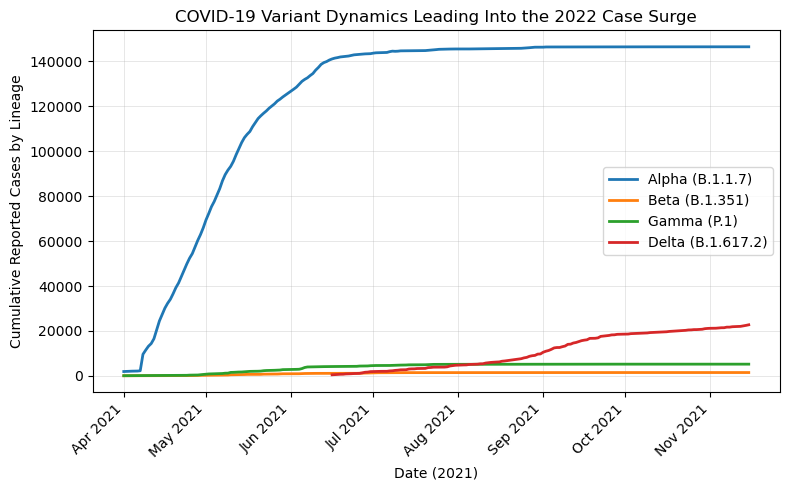

In [23]:
lineage_cols = [
    "Total_Lineage_B.1.1.7_Alpha",
    "Total_Lineage_B.1.351_Beta",
    "Total_Lineage_P.1_Gamma",
    "Total_Lineage_B.1.617.2_Delta",
]

# Ensure numeric
for col in lineage_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only rows with lineage data
df_lineage = df.dropna(subset=lineage_cols, how="all")

# -----------------------------
# Restrict to late 2021 only
# -----------------------------
df_late_2021 = df_lineage[
    (df_lineage["Reported Date"] >= "2021-04-01") &
    (df_lineage["Reported Date"] <= "2021-12-31")
]

# -----------------------------
# Plot: Variant contribution leading into 2022 peak
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_late_2021["Reported Date"],
    df_late_2021["Total_Lineage_B.1.1.7_Alpha"],
    label="Alpha (B.1.1.7)",
    linewidth=2
)
ax.plot(
    df_late_2021["Reported Date"],
    df_late_2021["Total_Lineage_B.1.351_Beta"],
    label="Beta (B.1.351)",
    linewidth=2
)
ax.plot(
    df_late_2021["Reported Date"],
    df_late_2021["Total_Lineage_P.1_Gamma"],
    label="Gamma (P.1)",
    linewidth=2
)
ax.plot(
    df_late_2021["Reported Date"],
    df_late_2021["Total_Lineage_B.1.617.2_Delta"],
    label="Delta (B.1.617.2)",
    linewidth=2
)

ax.set_title("COVID-19 Variant Dynamics Leading Into the 2022 Case Surge")
ax.set_xlabel("Date (2021)")
ax.set_ylabel("Cumulative Reported Cases by Lineage")

# Monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.grid(True, linewidth=0.6, alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()

### What software did you use to create your data visualization?
I used Python, with pandas for data cleaning and manipulation and matplotlib for creating the visualization.

### Who is your intended audience?
The intended audience is a general public health and academic audience interested in understanding COVID-19 variant dynamics.

### What information or message are you trying to convey with your visualization?
This visualization shows how different COVID-19 variants (Alpha, Beta, Gamma, and Delta) changed in prevalence over time in 2021. Based on visualization 1, the largest overall case peak occurs in early 2022. Also, lineage-specific data are only available in 2021, so the plot focuses on late 2021 to show which variants were spreading most leading into the 2022 surge. It shows that Delta emerged as the dominant contributor.

### What aspects of design did you consider when making your visualization? How did you apply them?
I prioritized comparability by plotting all variants on the same axes, using monthly date labels, consistent line styles, and a clear legend

### How did you ensure that your data visualizations are reproducible?
All steps from loading the dataset to filtering dates and generating the plot are written explicitly in code within the notebook, making the visualization easy to reproduce or modify.

### How did you ensure that your data visualization is accessible?
The visualization uses clear labels, a legend, and simple line encodings and avoids unnecessary visual clutter.

### Who are the individuals and communities who might be impacted by your visualization?
Understanding which variants were driving transmission before major case surges.

### How did you choose which features of your chosen dataset to include or exclude?
I excluded rows without lineage data and unrelated variables to keep the analysis focused.

### What ‘underwater labour’ contributed to your final data visualization product?
Underlying work included identifying the availability of lineage data, filtering to an appropriate time window, handling missing values, and refining the plot and annotations to accurately reflect data limitations.
